**We will begin with a Logistic Regression Model to predict the attrition of an employee**

In [50]:
import pandas as pd
from sklearn.linear_model import LogisticRegression

df = df = pd.read_csv(
    "../data/processed/Employee-Attrition_Regression_Ready.csv"
)
df.head()

df = df.drop(columns='Unnamed: 0')

The data is already processesd and ready to train a model in a previous notebook. All columns were converted into numeric values and all categories are one-hot encoded. The data frame needs to be split into an X and Y.
In the Attrition column, a 1 indicates an employee left, 0 means an employee stayed.

In [51]:
X = df.drop(columns='Attrition')
Y = df['Attrition']

print(X.shape)
print(Y.shape)

print(Y.value_counts())

(1470, 50)
(1470,)
Attrition
0    1233
1     237
Name: count, dtype: int64


Here we split the the data into a testing and training data. 'random_state' is like a seed that makes sure that everyone running the code gets the same result. But why 42? Because it's the answer to Life, the Universe, and Everything. 'satisfy' is needed, because we have far more non-attrition employees. This ensures the proportions are kept.

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, Y_train, Y_test = train_test_split(
    X, Y, test_size = 0.2, random_state = 42, stratify=Y
)

print(X_train.shape)
print(Y_train.shape)

(1176, 50)
(1176,)


Time to actually train the model.

In [53]:
logistic_model = LogisticRegression(max_iter = 1000, random_state = 42)

logistic_model.fit(X_train, Y_train)

Y_pred = logistic_model.predict(X_test)

Now we test the model's accuracy.

In [54]:
from sklearn.metrics import accuracy_score

accuracy =  accuracy_score(Y_test, Y_pred)

print(f"Accuracy: {round((accuracy * 100), 2)}%")

Accuracy: 86.05%


Interesting score, but we need further evaluation to really understand what's going on. Let's use a classification report.

In [55]:
from sklearn.metrics import classification_report

print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       0.88      0.96      0.92       247
           1       0.62      0.34      0.44        47

    accuracy                           0.86       294
   macro avg       0.75      0.65      0.68       294
weighted avg       0.84      0.86      0.84       294



See the row '1', employees who left, 'precision' and 'recall' give important information. 
* 1. Percision states: of employees predicted to leave, how many actually left? Only 62%.
* 2. Recall states: of employees who left, how many did the model successfully identify? Only 34%

See the row '0', employees who stayed.
* 1. Of the employees predicted to stay, how many actually stayed? 88%
* 2. Of the employees who stayed, how many did the model correctly predict? 96%

What does this tell us?
* The model excells at predicting if an employee stays but is less accurate at identifing employees who actually left.

A confusion matrix will help illustrate this.

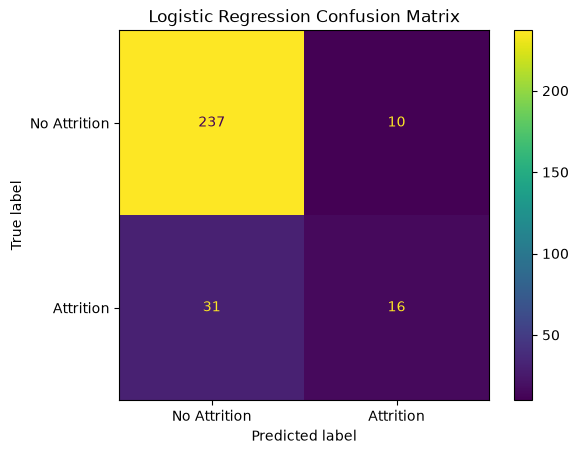

In [56]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, Y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=['No Attrition', 'Attrition']
)

disp.plot()
plt.title('Logistic Regression Confusion Matrix')
plt.show()

Here we see an absolute yes or no answer to if an employee will leave the company. However, a more useful metric will be how likely an employee will leave, as it can leave a better analysis on attrition.

In [57]:
Y_prob = logistic_model.predict_proba(X_test)[:, 1]
print([f"{x * 100:.2f}%" for x in Y_prob])

['7.82%', '0.30%', '16.51%', '0.55%', '31.31%', '26.81%', '0.82%', '1.76%', '0.39%', '9.71%', '5.50%', '7.78%', '37.58%', '18.24%', '28.29%', '40.69%', '1.65%', '0.72%', '27.14%', '1.28%', '44.06%', '11.17%', '10.62%', '1.61%', '0.56%', '51.84%', '9.11%', '6.72%', '0.86%', '1.67%', '0.62%', '15.04%', '5.55%', '5.42%', '18.81%', '81.51%', '3.61%', '2.82%', '5.61%', '50.26%', '0.26%', '55.31%', '1.37%', '4.58%', '12.35%', '4.66%', '38.14%', '35.56%', '2.47%', '6.23%', '9.40%', '3.52%', '1.75%', '23.36%', '1.72%', '2.96%', '3.08%', '79.26%', '9.19%', '2.12%', '3.73%', '0.36%', '1.96%', '9.52%', '8.52%', '2.55%', '16.57%', '24.29%', '8.49%', '3.03%', '33.89%', '0.58%', '0.43%', '8.64%', '4.62%', '0.82%', '0.06%', '0.77%', '16.18%', '1.77%', '2.87%', '85.46%', '0.32%', '0.06%', '3.20%', '12.83%', '0.26%', '7.99%', '3.45%', '5.86%', '2.41%', '0.25%', '96.55%', '22.87%', '23.23%', '85.39%', '62.07%', '5.21%', '17.55%', '39.95%', '0.21%', '60.99%', '12.51%', '2.15%', '64.18%', '3.20%', '8.18%'

In [58]:
results = pd.DataFrame({
    'Employee': X_test.index,
    'Probability of Leaving': Y_prob,
    'Prediction': Y_pred
})

results['Probability of Leaving'] = (
    results['Probability of Leaving'] * 100
).round(2)

results['Prediction'] = results['Prediction'].map({
    0: 'Stay',
    1: 'Leave'
})

results

,Employee,Probability of Leaving,Prediction
0,1061,7.82,Stay
1,891,0.30,Stay
2,456,16.51,Stay
3,922,0.55,Stay
4,69,31.31,Stay
...,...,...,...
289,1269,1.38,Stay
290,1352,0.99,Stay
291,1236,48.07,Stay
292,1023,0.95,Stay


As we can see, we now have a **PROBABILITY** of attrition. The model makes a hard prediction of the employee leaving decision when the probability exceeds 50%. Anything less and the model says the employee didn't leave.

Let's have one last model evaluation to judge how effective the model was at predicting attrition. This test is called the ROC-AUC, which evaluates the model's ability to rank higher-risk employees above lower-risk employees. 

In practice, we get a number between 0.5 and 1.0. 
* 0.5 indicating the model is essentially guessing at random
* 1.0 indicating the model predicts perfectly
* Our model scored around 0.81, which is good performance

In [ ]:
from sklearn.metrics import roc_auc_score

auc = roc_auc_score(Y_test, Y_prob)

print("ROC-AUC:", auc)

Let's see which columns had the most impact on predicting Employee attrition.

In [59]:
coefficients = pd.DataFrame({
    'Feature': X_train.columns,
    'Coefficient': logistic_model.coef_[0]
})

coefficients = coefficients.sort_values(
    'Coefficient',
    ascending=False
)

print(coefficients)

                              Feature  Coefficient
12                           OverTime     1.804842
40      JobRole_Laboratory Technician     1.036513
25   BusinessTravel_Travel_Frequently     0.903569
46       JobRole_Sales Representative     0.885409
30     EducationField_Human Resources     0.616778
22            YearsSinceLastPromotion     0.533677
49               MaritalStatus_Single     0.489348
11                 NumCompaniesWorked     0.482766
35    EducationField_Technical Degree     0.411638
2                    DistanceFromHome     0.376778
39            JobRole_Human Resources     0.330278
29                   Department_Sales     0.309895
7                            JobLevel     0.206221
14                  PerformanceRating     0.197615
20                     YearsAtCompany     0.167501
37                        Gender_Male     0.166957
32           EducationField_Marketing     0.096537
26       BusinessTravel_Travel_Rarely     0.018315
10                        Month

The numbers show an impact of each column on attrition. A positive number means that the column is associated with a greater chance of attrition. While a negative number indicates the column is associates with lower chance of attrition.